In [15]:
# Load and analyse the waveforms and extract the event charge and peaking time , along with SPE,ECF values using finger plots
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pypeaks import Data, Intervals
import pandas as pd
import math

In [44]:
# Function to get the timestamps of the waveform
np.Inf = np.inf
def getTime(time,dt):
    return time + dt

def gauss(x,A,mu,sig):
        return A*np.exp(-(x-mu)**2/(2*sig**2)) 

def gaussian_fit_C(max,min): # fitting the charge histogram for a specific peak defined by the max and min, 
                             # by fitting to the baseline hitogram/pedastal and subtracting the mean from 0, we get the offset in Volts, 
                             # we can then shift to have zero histogram shifted based on the offset, such that it is centred on zero V
                             # by fitting to the next hitogram/single photon detection histogram and the mean gives us the Single photo electron in Vs
                             # Gain of the CSP* SPE in V= SPE in Coulombs    
    x=np.linspace(min,max,1000)
    n,bin=np.histogram(peaks, bins=1000, range=(min,max))
    y=n
    ind_mean=np.argmax(n)
    popt,pcov=curve_fit(gauss,x,y,(np.max(n),bin[ind_mean],0.001))
    y=gauss(x,popt[0],popt[1],popt[2])
    return x,y,popt

def gaussian_fit_A(number,data):      # specifically for finding the number^th peak on the avalanche histogram
    n_, bins_= np.histogram(data, bins=1000, range=(-2.5,10))
    data_obj = Data(bins_[:-1], n_, smoothness=11)
    data_obj.get_peaks(method='slope')
    min=[]
    max=[]
    min=[data_obj.peaks["valleys"][0][0], data_obj.peaks["valleys"][0][2]]
    max=[data_obj.peaks["valleys"][0][1], data_obj.peaks["valleys"][0][3]]

    
    n,bin=np.histogram(data, bins=1000, range=(min[number],max[number]))
    bin_centers = (bin[:-1] + bin[1:]) / 2
    x = bin_centers
    y=n
    ind_mean=np.argmax(n)
    popt,pcov=curve_fit(gauss,x,y,(np.max(n),x[ind_mean],0.001))
    y_fit=gauss(x,popt[0],popt[1],popt[2])
    return x,y_fit,popt

open_data_dir= 'waveforms'
voltage_dirs = os.listdir(open_data_dir)[1:]

avg_q=[]
ecf=[]
spe=[]
vol=[]
for voltage_dir in voltage_dirs:
    
    dir_name = 'waveforms/'+voltage_dir
    waveforms = np.load(dir_name+'/waveforms.npy')
    time = np.load(dir_name+'/time.npy')
    ttime = np.load(dir_name+'/ttime.npy')
    #parameters= np.load(dir_name+'/parameters.npy')
    charge = np.array([])

    tdist = np.diff(ttime)
    vol=np.append(vol, float(voltage_dir[:2]))
    peaks=[]
    for i in range(len(waveforms)):
        peaks= np.append(peaks,np.max(waveforms[i]))  # we need peaks in mV since the gain is in mV/pC  
        #print(wfm)
        #Uncomment to plot the fourth waveform
        #if (waveforms[i]==waveforms[3]).all():
            #plt.figure()
            #plt.plot(time,waveforms[i]) # Using I=V/R
            #plt.xlabel('Time (s)')
            #plt.ylabel('Current (A)')
            #plt.show()
        

    # Uncomment to use when there is no Charge Sensitive Preamplifier Amplifier and only an RF amplifier in your setup. 
    #charge sensitive preamplifier will have a gain with units of mV/pC, or something similar (volts/coulomb),
    #pulse that comes out of the amplifier will have an amplitude that is linearly proportional to the charge that flows into it
        #charge = np.append(charge,np.sum(waveforms[i]*(time[1]-time[0]))/50) 
    #avalanches = charge/1.6e-19/1e6
    #intensity = avalanches/0.3

    # Curve fitting - zero avalanche charge hist
    
    #Obtaining the gaussian fit parameters
    popt0=[]
    popt1=[]
    popt0=gaussian_fit_C(0.0,-0.1)[2]
    popt1=gaussian_fit_C(0.05,-0.0075)[2]   
    # To find max and min values, either first fit the charge histograms for the lowest voltage waveforms and then adjust the ranges according to the highest 
    # voltage histograms or implement a histogram peak finder algorithm on the charge histogram like in gaussian_fit_A

    #Avg Charge of the histogram i.e. avg charge present in the pulses at the given bias voltage
    q_n,q_bins=np.histogram((peaks-popt0[1])*1000/100.1, bins=1000)
    q_bin_cen=0
    q_bin_cen=(q_bins[:-1] + q_bins[1:]) / 2
    avg_q=np.append(avg_q, np.average(q_bin_cen, weights=q_n))
    #SPE (Single Photo Electron Calculation)
    spe=np.append(spe,popt1[1]-popt0[1])
    
    #Fitting the Zero Avalanche Histogram 
    poptA0=[]
    poptA0=gaussian_fit_A(0,peaks/spe[-1])[2]          #gaussian_fit(0.0,-1.0)[2]
    #Calculating the mean no of avalanches using the Zeroed Avalanche Histogram
    ava_n, ava_bins= np.histogram(peaks/spe[-1]-poptA0[1], bins=1000, range=(-2,10))
    avg_ava=0
    bin_centres=0
    bin_centers=(ava_bins[:-1] + ava_bins[1:]) / 2
    avg_ava = np.average(bin_centers, weights=ava_n)  

    #Calculating the Excess Charge Factor(ECF)
    
   
    #n0=np.argwhere((-3*poptA0[2]<ava_n)&(ava_n<3*poptA0[2])) #99.7% of the data from the gaussian distribution falls within the 3 sigma range
    mu=0
    A0_ind=np.where(peaks<-0.009) # indices of waveforms with 0 avalanches
    mu=-np.log(len(A0_ind[0][:])/len(waveforms)) # Here mu is  no. of photons detected wichout correcting for randomly detected dark count events, refer to simulating and understanding SiPMS
    ecf=np.append(ecf, avg_ava/mu)
    print(voltage_dir, 'has been processed')

vol=vol.astype('i')



49V-02 has been processed
48V-03 has been processed
49V-04 has been processed
47V-01 has been processed
51V-01 has been processed
45V-01 has been processed
44V-01 has been processed
50V-01 has been processed
43V-01 has been processed
49V-01 has been processed
47V-02 has been processed
44V-03 has been processed
51V-03 has been processed
45V-03 has been processed
45V-04 has been processed
51V-04 has been processed
46V-02 has been processed
44V-02 has been processed
50V-02 has been processed
47V-04 has been processed
47V-03 has been processed
46V-03 has been processed
46V-04 has been processed
51V-02 has been processed
45V-02 has been processed
43V-04 has been processed
43V-02 has been processed


In [45]:
file_path = "Pulse_Analysis_CH2.csv"  # Replace with your CSV file path
data = pd.read_csv(file_path)
Vol_csv=data["Voltage"]
spe_csv=data["V_SPE"]/1000
ecf_csv=data["ECF"]
avg_q_csv=data["Q_excess (V_mu_actual/CSP_gain) pC"]
ovol_csv=data["V_over"]


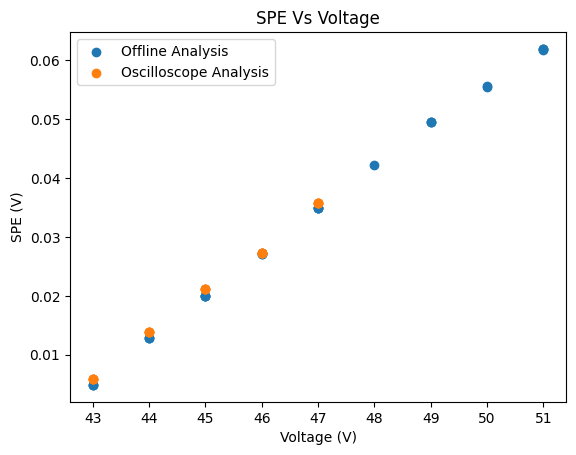

In [46]:
#Plotting graphs
# SPE vs Voltage to identify breakdown voltage
plt.scatter(vol,spe, label="Offline Analysis" )
plt.scatter(Vol_csv,spe_csv, label="Oscilloscope Analysis")
plt.title('SPE Vs Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('SPE (V)')
plt.legend()


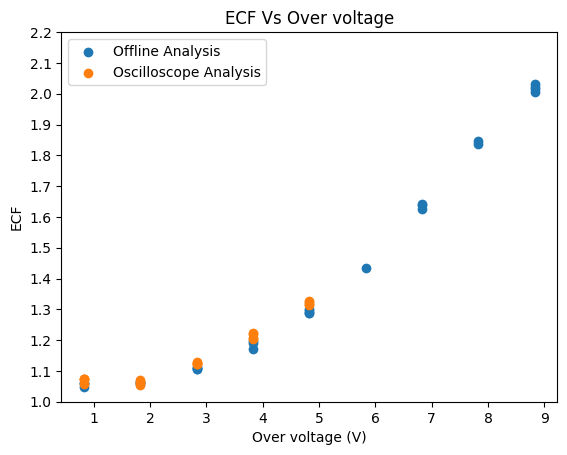

In [47]:
plt.scatter(vol-42.17,ecf, label="Offline Analysis")
plt.scatter(ovol_csv,ecf_csv, label="Oscilloscope Analysis")
plt.yticks(np.arange(1, 2.2, step=0.1))
plt.title('ECF Vs Over voltage')
plt.xlabel('Over voltage (V)')
plt.ylabel('ECF')
plt.legend()

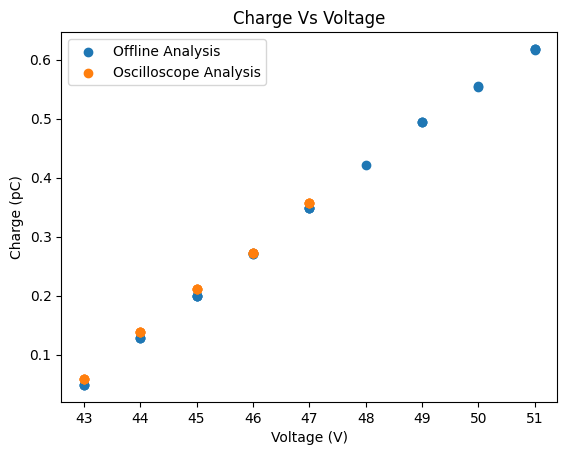

In [48]:
plt.scatter(vol,spe*1000/100.1, label="Offline Analysis" ) # Dividing by CSP gain which is 100.1/1000 V/pC
plt.scatter(Vol_csv,spe_csv*1000/100.1, label="Oscilloscope Analysis")
plt.title('Charge Vs Voltage') # charge in single photo electron
plt.xlabel('Voltage (V)')
plt.ylabel('Charge (pC)')
plt.legend()

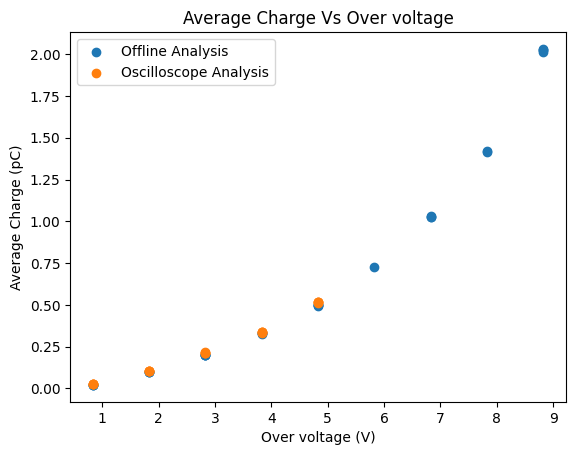

In [49]:
#This is not the plot for finding the capacitance, as this Avg charge
plt.scatter(vol-42.17,avg_q,label="Offline Analysis")
plt.scatter(ovol_csv,avg_q_csv, label="Oscilloscope Analysis")
plt.title('Average Charge Vs Over voltage')
plt.xlabel('Over voltage (V)')
plt.ylabel('Average Charge (pC)')
plt.legend()


In [41]:
ava_n, ava_bins= np.histogram(peaks, bins=1000, range=(-2,10))

In [60]:
ava_bins

array([-2.   , -1.988, -1.976, ...,  9.976,  9.988, 10.   ])

In [74]:
from pypeaks import Data, Intervals

ava_n, ava_bins= np.histogram(peaks, bins=1000, range=(-2,10))
data_obj = Data(ava_bins[:-1], ava_n, smoothness=11)

#Peaks by slope method
data_obj.get_peaks(method='slope')
#print data_obj.peaks
data_obj.plot()

#Peaks by interval method
#ji_intervals = ava_bins
#ji_intervals = Intervals(ji_intervals)
#data_obj.get_peaks(method='interval', intervals=ji_intervals)
data_obj.peaks
#data_obj.plot(intervals=ji_intervals)

ValueError: attempt to get argmin of an empty sequence

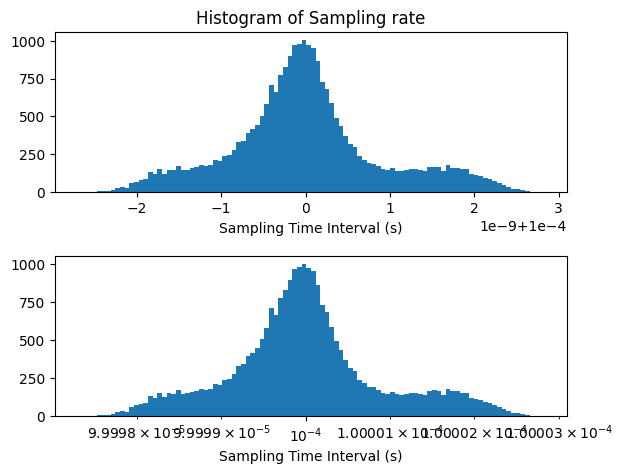

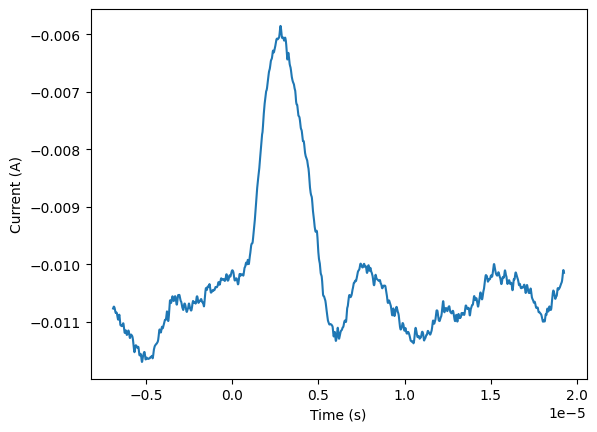

<Figure size 640x480 with 0 Axes>

[ 0.00085224 -0.00984545 -0.00966866 ... -0.009698   -0.00969414
 -0.00986861]


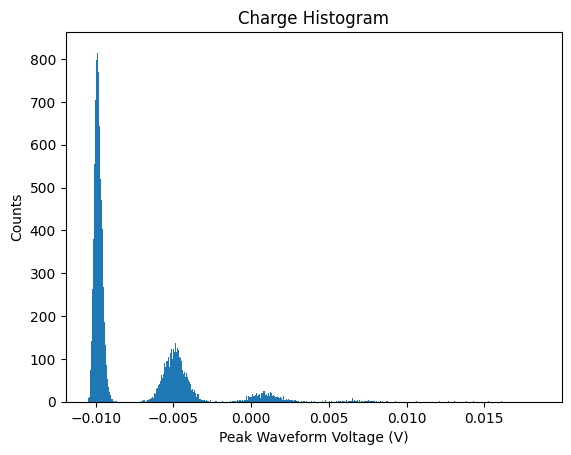

In [16]:
#use the code below to plot histograms for individual voltage files in voltage_dirs

# Function to get the timestamps of the waveform
def getTime(time,dt):
    return time + dt

# Set the path to the data file
dir_name = 'waveforms/43V-01'
#dir_name = 'waveforms/RefCurve_2023-12-08_2_022855'

waveforms = np.load(dir_name+'/waveforms.npy')
time = np.load(dir_name+'/time.npy')
ttime = np.load(dir_name+'/ttime.npy')
#parameters= np.load(dir_name+'/parameters.npy')
charge = np.array([])

tdist = np.diff(ttime)

# histogram on log scale. 
plt.subplot(211)
plt.title('Histogram of Sampling rate')
plt.xlabel('Sampling Time Interval (s)')
hist, bins, _ = plt.hist(tdist, bins=100)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.4)
# Use non-equal bin sizes, such that they look equal on log scale.
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))

plt.subplot(212)
plt.hist(tdist, bins=logbins)
plt.xscale('log')
plt.xlabel('Sampling Time Interval (s)')
plt.show()


peaks=[]
for i in range(len(waveforms)):
    #print(wfm)
    # Plot the fourth waveform
    if (waveforms[i]==waveforms[3]).all():
        plt.figure()
        plt.plot(time,waveforms[i]) # Using I=V/R
        plt.xlabel('Time (s)')
        plt.ylabel('Current (A)')
        plt.show()
    peaks= np.append(peaks,np.max(waveforms[i]))  # we need peaks in mV since the gain is in mV/pC  

    # Uncomment to use when there is no Charge Sensitive Preamplifier Amplifier and only an RF amplifier in your setup. 
#charge sensitive preamplifier will have a gain with units of mV/pC, or something similar (volts/coulomb),
#pulse that comes out of the amplifier will have an amplitude that is linearly proportional to the charge that flows into it
    #charge = np.append(charge,np.sum(waveforms[i]*(time[1]-time[0]))/50) 
   
#avalanches = charge/1.6e-19/1e6
#intensity = avalanches/0.3


plt.figure()
#plt.hist(charge, bins=100)
#plt.title('Charge Histogram')
plt.show()
plt.hist(peaks, bins=1000)  # For charge divide by 100.1 mV/pC since it is the gain of the CSP found through calibration. 
#By eyeballing +1.19 is the baseline correction found by adding the negative charge*100 taken from waveform[3]  i.e. peaks[3]*100
plt.title('Charge Histogram')
plt.xlabel('Peak Waveform Voltage (V)')
plt.ylabel('Counts')
#plt.xlim(-2,2)

#np.where(peaks[i]==0.01, i, print(i))
print(peaks)

[ 2.69961381e+03 -9.83317059e-03  2.41793317e-04]


Text(0, 0.5, 'Counts')

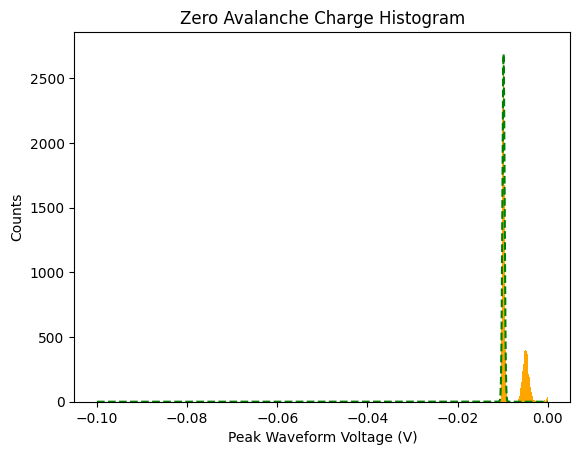

In [17]:
# Curve fitting - zero avalanche charge hist
def gauss(x,A,mu,sig):
    return A*np.exp(-(x-mu)**2/(2*sig**2))


max=0.0#-0.0075
min=-0.1#-0.015
x=np.linspace(min,max,1000)
#plt.hist(peaks, bins=100, range=(min,max))  
n,bin,patches=plt.hist(peaks, bins=1000, range=(min,max), color='orange')
y=n
ind_mean=np.argmax(n)
popt0,pcov0=curve_fit(gauss,x,y,(np.max(n),bin[ind_mean],0.001))
print(popt0)

y=gauss(x,popt0[0],popt0[1],popt0[2])
plt.plot(x,y, color='green', linestyle='dashed')
plt.title('Zero Avalanche Charge Histogram')
plt.xlabel('Peak Waveform Voltage (V)')
plt.ylabel('Counts')

[ 2.35758696e+02 -4.95433190e-03  6.71037994e-04]


Text(0, 0.5, 'Counts')

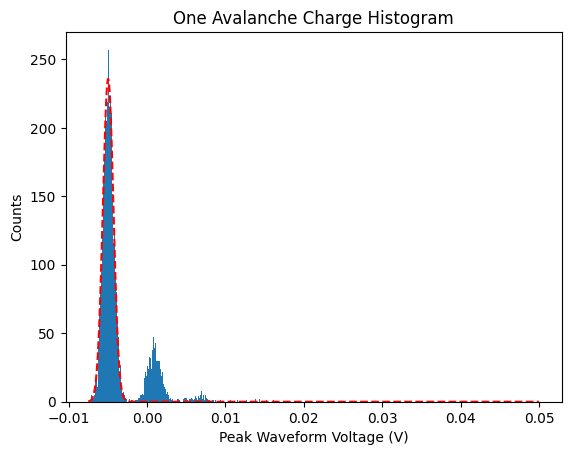

In [18]:
# Curve fitting: 1 avalanche charge hist
def gauss(x,A,mu,sig):
    return A*np.exp(-(x-mu)**2/(2*sig**2))


max=0.05
min=-0.0075
x=np.linspace(min,max,1000)
#plt.hist(peaks, bins=100, range=(min,max), color='blue')  
n,bin,patches=plt.hist(peaks, bins=1000, range=(min,max))
y=n
ind_mean=np.argmax(n)
popt1,pcov1=curve_fit(gauss,x,y,(np.max(n),bin[ind_mean],0.001))
print(popt1) # amplitude, mean, std deviation

y=gauss(x,popt1[0],popt1[1],popt1[2])
plt.plot(x,y, color='red', linestyle='dashed')
plt.title('One Avalanche Charge Histogram')
plt.xlabel('Peak Waveform Voltage (V)')
plt.ylabel('Counts')

np.float64(0.02118537875650095)

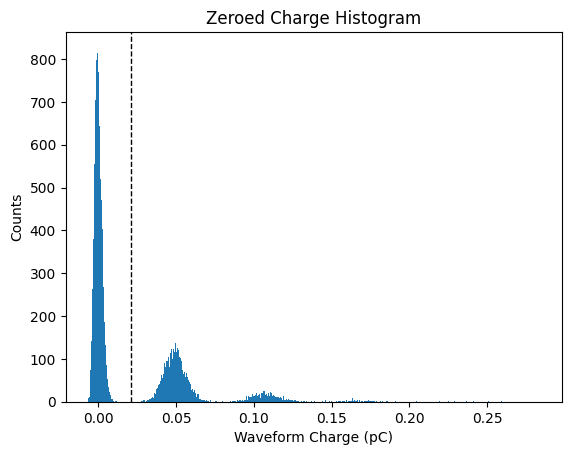

In [19]:
plt.show()
q_n,q_bins,q_patches=plt.hist((peaks-popt0[1])*1000/100.1, bins=1000)
# For charge divide by 100.1 mV/pC since it is the gain of the CSP found through calibration. 
#Multiply by 1000 to get voltages in mV since gain is in mv/pC
#By eyeballing +0.0119 is the baseline correction found by adding the negative charge taken from waveform[3]  i.e. peaks[3]*100
plt.title('Zeroed Charge Histogram')
plt.xlabel('Waveform Charge (pC)')
plt.ylabel('Counts')

#Avg Charge of the histogram i.e. avg charge present in the pulses at the given bias voltage
avg_q=0
q_bin_cen=0
q_bin_cen=(q_bins[:-1] + q_bins[1:]) / 2
avg_q= np.average(q_bin_cen, weights=q_n)
plt.axvline(avg_q, color='k', linestyle='dashed', linewidth=1)
avg_q


In [20]:
spe=popt1[1]-popt0[1]
print('SPE=',spe)

SPE= 0.004878838688634918


Text(0, 0.5, 'Counts')

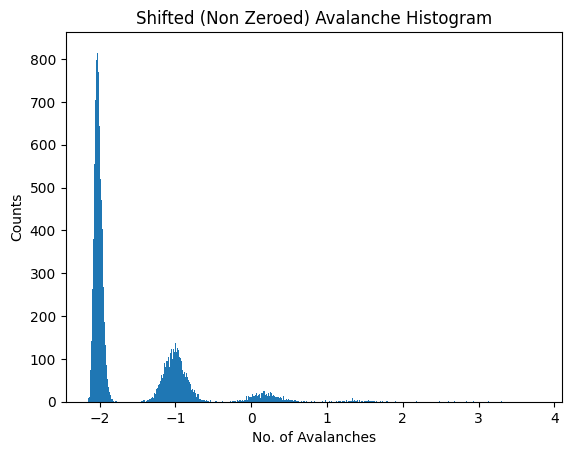

In [21]:
# Avalanche histogram needs to be zeroed
#plt.hist(charge, bins=100)
#plt.title('Charge Histogram')

n,bins,patches=plt.hist(peaks/spe, bins=1000)
#By eyeballing +1.19 is the baseline correction found by adding the negative charge*100 taken from waveform[3]  i.e. peaks[3]*100
plt.title('Shifted (Non Zeroed) Avalanche Histogram')
plt.xlabel('No. of Avalanches')
plt.ylabel('Counts')
#print(n)

[ 2.47165803e+02 -2.03189133e+00  5.95551738e-02]


Text(0, 0.5, 'Counts')

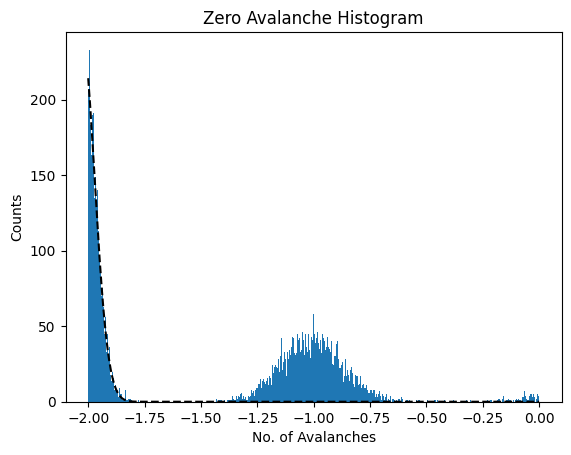

In [38]:

# Curve fitting - zero avalanche , avalanche hist
def gauss(x,A,mu,sig):
    return A*np.exp(-(x-mu)**2/(2*sig**2))

max=-0.0
min=-2.0
x=np.linspace(min,max,1000)
#plt.hist(peaks/spe, bins=100, range=(min,max))  
n,bin,patches=plt.hist(peaks/spe, bins=1000, range=(min,max))
y=n
ind_mean=np.argmax(n)
poptA0,pcovA0=curve_fit(gauss,x,y,(np.max(n),bin[ind_mean],0.01))
print(poptA0)

y=gauss(x,poptA0[0],poptA0[1],poptA0[2])
plt.plot(x,y, color='black', linestyle='dashed')
plt.title('Zero Avalanche Histogram')
plt.xlabel('No. of Avalanches')
plt.ylabel('Counts')

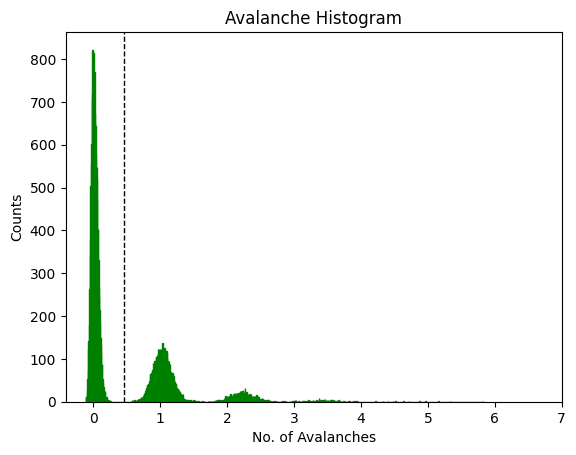

Avg no. of observed avalanches= 0.45108190213384636
Mean number of expected avalanches = 0.4222044321124625
Excess Charge Factor= 1.0683968898121177


In [39]:
ava_n, ava_bins, ava_patches= plt.hist(peaks/spe-poptA0[1], bins=1000, edgecolor='green')
#avg_ava=np.mean((peaks)/spe-poptA0[1])/(len(bins)-1)
avg_ava=0
bin_centres=0
bin_centers=(ava_bins[:-1] + ava_bins[1:]) / 2
avg_ava = np.average(bin_centers, weights=ava_n)

# or use the code below which does the same thing
#n_sum=np.sum(ava_n)
#avg_ava=0
#for i in range(0,len(ava_bins)-1):
#   avg_ava=avg_ava+(ava_n[i]*(ava_bins[i+1]+ava_bins[i])/(n_sum*2))
#print(avg_ava)

plt.axvline(avg_ava, color='k', linestyle='dashed', linewidth=1)
plt.xticks(np.arange(0, 8, step=1))
plt.title('Avalanche Histogram')
plt.xlabel('No. of Avalanches')
plt.ylabel('Counts')
plt.show()
print('Avg no. of observed avalanches=', avg_ava)


#The no below is histogram dependent and not on the sampling rate of the oscilliscope
# n0=np.argwhere((-1*poptA0[2]<ava_n)&(ava_n<1*poptA0[2])) #99.7% of the data from the gaussian distribution falls within the 3 sigma range
A0_ind=np.where(peaks<-0.009) # indices of waveforms with 0 avalanches
mu=0
mu=-np.log(len(A0_ind[0][:])/len(waveforms))
ecf=avg_ava/mu
print('Mean number of expected avalanches =', mu) #from sampling rate
print('Excess Charge Factor=', ecf)



In [ ]:
A0_ind=np.where(peaks<-0.009)
len(A0_ind[0][:])

array([    1,     2,     4, ..., 24996, 24997, 24999])

In [50]:
ava_bins[np.argmax(ava_n)]

-0.011012772039862742

In [68]:
voltage_dirs

['49V-02',
 '48V-03',
 '49V-04',
 '47V-01',
 '51V-01',
 '45V-01',
 '44V-01',
 '50V-01',
 '43V-01',
 '49V-01',
 '47V-02',
 '44V-03',
 '51V-03',
 '45V-03',
 '45V-04',
 '51V-04',
 '46V-02',
 '44V-02',
 '50V-02',
 '47V-04',
 '47V-03',
 '46V-03',
 '46V-04',
 '51V-02',
 '45V-02',
 '43V-04',
 '43V-02']

In [47]:
sort_ava_n=np.sort(ava_n)
sort_ava_n[-2]
index=np.where(ava_n==sort_ava_n[-2])
ava_bins[index]


array([0.00143042])

In [50]:
ava_bins[8]

0.00851997969327329

In [67]:
ind=np.where((ava_bins<1.5)&(ava_bins>0.5))
ava_bins[np.argmax(ava_n[ind])]
ava_n[ind]

array([  0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         0.,   0.,   0.,   1.,   1.,   0.,   1.,   3.,   5.,   7.,   7.,
        10.,  10.,  14.,  19.,  36.,  29.,  60.,  66.,  88., 110., 137.,
       154., 191., 249., 276., 267., 299., 319., 332., 346., 385., 426.,
       385., 386., 430., 379., 409., 360., 384., 289., 270., 242., 220.,
       187., 165., 142., 100.,  86.,  74.,  51.,  50.,  32.,  22.,  14.,
        15.,  13.,  10.,   4.,   7.,   3.,   5.,   8.,   6.,   2.,   4.,
         7.,   6.,   3.,   3.,   1.,   2.,   4.,   4.,   2.,   4.,   3.,
         4.,   2.,   0.,   2.,   0.,   4.,   2.,   4.,   2.,   2.,   2.,
         2.,   1.,   2.,   0.,   2.,   1.,   1.,   0.,   2.])